In [1]:
import os, random, json
import numpy as np
import pandas as pd

from dotenv import load_dotenv
from openai import OpenAI
from googleapiclient.discovery import build

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
load_dotenv()

True

In [3]:
# OpenAI Token eingeben
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [10]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Keys and video ID
VIDEO_ID = "7uG2gYE5KOs"
YOUTUBE_API_KEY = os.getenv("YOUTUBE_DATA_API_KEY")
MAX_PAGES = 5
ORDER = "relevance"

## YouTube Kommentare holen



In [11]:



def fetch_comments(video_id: str, api_key: str, max_pages: int = 5, order: str = "relevance"):
    yt = build("youtube", "v3", developerKey=api_key, static_discovery=False)
    comments = []
    page_token = None
    pages = 0
    while pages < max_pages:
        resp = yt.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=100,
            pageToken=page_token,
            textFormat="plainText",
            order=order
        ).execute()
        for item in resp.get("items", []):
            top = item["snippet"]["topLevelComment"]["snippet"]
            text = (top.get("textDisplay") or top.get("textOriginal") or "").strip()
            if not text:
                continue
            comments.append({
                "comment_id": item["id"],
                "text": text,
                "likeCount": int(top.get("likeCount", 0)),
                "publishedAt": top.get("publishedAt", ""),
                "author": top.get("authorDisplayName", "")
            })
        page_token = resp.get("nextPageToken")
        pages += 1
        if not page_token:
            break
    return pd.DataFrame(comments)

df = fetch_comments(VIDEO_ID, YOUTUBE_API_KEY, max_pages=MAX_PAGES, order=ORDER)
print(len(df))
df.head()

500


,comment_id,text,likeCount,publishedAt,author
0,UgyP0wlB6ydmJGKEXqV4AaABAg,Her music is timeless. I'm 70 and still love h...,712,2024-04-01T02:07:50Z,@debra53758
1,UgxvTfPlChEGB4I3i8x4AaABAg,I’m 70 I saw Janis in the 70s along with Hendr...,845,2024-01-07T02:20:35Z,@Back2blonde
2,UgwOwIOdXGWBVm_haZt4AaABAg,I love how she pulled that shy girl to her and...,1439,2020-01-12T20:38:46Z,@maysclimate9443
3,UgzSCgaE1I00jX7HM2t4AaABAg,Wish she was here to see how many people STILL...,152,2024-04-16T01:18:50Z,@WalturdTheCat
4,UgxJoLgISMrdJZ6pooR4AaABAg,"She had ""IT"" whatever ""IT"" is..... She's got i...",1940,2022-03-27T03:23:46Z,@jamesgreen6608


In [12]:
docs = df["text"].tolist()

vectorizer_model = CountVectorizer()
topic_model = BERTopic(vectorizer_model=vectorizer_model, language="english", calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(docs)

2025-09-30 03:13:03,316 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

2025-09-30 03:13:06,038 - BERTopic - Embedding - Completed ✓
2025-09-30 03:13:06,038 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-09-30 03:13:06,262 - BERTopic - Dimensionality - Completed ✓
2025-09-30 03:13:06,263 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-09-30 03:13:06,273 - BERTopic - Cluster - Completed ✓
2025-09-30 03:13:06,275 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-09-30 03:13:06,284 - BERTopic - Representation - Completed ✓


10it [00:00, 188.70it/s]


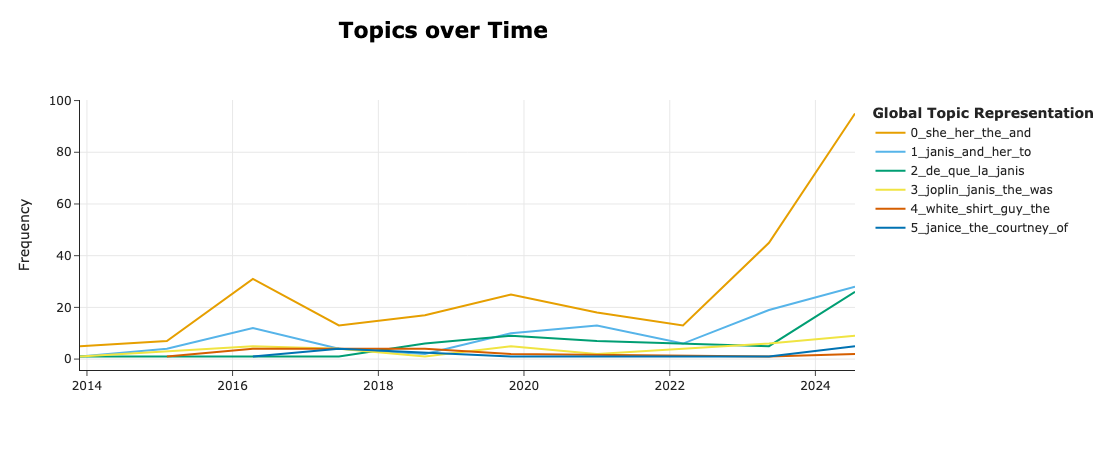

In [13]:

df["publishedAt"] = pd.to_datetime(df["publishedAt"], errors="coerce")
df = df.dropna(subset=["publishedAt"])

topics_over_time = topic_model.topics_over_time(
    docs,
    topics=topics,                
    timestamps=df["publishedAt"],
    nr_bins=10
)

fig = topic_model.visualize_topics_over_time(topics_over_time)
fig.show()

In [14]:
def summarize_trend(topic_id, tot_df, topn=10, seed=SEED):
    sub = tot_df[tot_df.Topic==topic_id]
    series = sub[["Timestamp", "Frequency"]].to_dict(orient="records")
    keywords = [kw for kw, _ in topic_model.get_topic(topic_id)[:topn]]
    prompt = f"""
    Hier sind die zeitlichen Häufigkeiten eines Themas in YouTube-Kommentaren:
    {series}

    Die Schlüsselwörter für das Thema: {keywords}

    Bitte fasse auf Deutsch zusammen, wie sich dieses Thema im Laufe der Zeit entwickelt:
    - Wann es stärker diskutiert wurde
    - Ob es zunimmt, abnimmt oder konstant bleibt
    - Welche inhaltliche Tendenz es hat
    Antworte mit 3-4 Sätzen.
    """
    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        seed=seed,
        messages=[{"role":"user","content":prompt}]
    )
    return resp.choices[0].message.content.strip(), resp.system_fingerprint

trend_summaries = {}
for tid in set(topics):
    if tid == -1:
        continue
    summary, fp = summarize_trend(tid, topics_over_time)
    trend_summaries[tid] = {"summary": summary, "system_fingerprint": fp}

trend_summaries


{0: {'summary': 'Das Thema zeigt eine deutliche Zunahme der Diskussion im Laufe der Zeit, insbesondere ab dem Jahr 2023, als die Häufigkeit mit 45 Kommentaren einen Höhepunkt erreichte, gefolgt von einem noch stärkeren Anstieg im Jahr 2024 mit 95 Kommentaren. Die Frequenzen schwankten zwischen 5 und 31 in den vorherigen Jahren, was darauf hinweist, dass das Interesse über die Jahre hinweg wuchs, obwohl es zwischen 2015 und 2018 einen leichten Rückgang gab. Die Verwendung von häufigen Keywords wie „she“ und „her“ deutet darauf hin, dass das Thema möglicherweise geschlechtsspezifische oder persönliche Aspekte behandelt, die in der aktuellen Diskussion verstärkt in den Fokus geraten. Insgesamt scheint das Thema eine positive Tendenz aufzuweisen, mit steigendem Interesse und Engagement in den letzten Jahren.',
  'system_fingerprint': 'fp_560af6e559'},
 1: {'summary': 'Das Thema wurde besonders stark zwischen 2023 und 2024 diskutiert, wobei die Frequenz im Juli 2024 mit 28 Kommentaren ihren

In [15]:
os.makedirs("./outputs", exist_ok=True)

# Save topics over time dataframe
tot_path = "./outputs/topics_over_time.csv"
topics_over_time.to_csv(tot_path, index=False)

# Save GPT summaries
summ_path = "./outputs/topic_trend_summaries.json"
with open(summ_path, "w", encoding="utf-8") as f:
    json.dump(trend_summaries, f, ensure_ascii=False, indent=2)

print("Saved:", tot_path, summ_path)

Saved: ./outputs/topics_over_time.csv ./outputs/topic_trend_summaries.json
